<a href="https://colab.research.google.com/github/kundana12345/DataScience/blob/main/Kundana_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

When your data is really complicated, having a polynomial element can be helpful.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

Polynomials can lead to overfitting.

**Task3**:

What's the point of using b splines?

It helps us used polynomial elements while reducing the overfitting that happens. It splits the data into different sections and tries to predit each section by itself.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

It has multiple splines that choose their own knots and it sort of splits the data and uses splines and knots to form a model for each seperate part.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [7]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [8]:
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [2]:
!pip install preliz
!pip install bambi

  Using cached arviz_stats-1.0.0-py3-none-any.whl.metadata (2.9 kB)
Using cached arviz_stats-1.0.0-py3-none-any.whl (171 kB)
  Using cached formulae-0.6.2-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 9.6 MB/s eta 0:00:00
Using cached formulae-0.6.2-py3-none-any.whl (54 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: arviz-stats
    Found existing installation: arviz-stats 1.0.0
    Uninstalling arviz-stats-1.0.0:
      Successfully uninstalled arviz-stats-1.0.0


In [3]:
import bambi as bmb

In [ ]:
#used Gemini

In [ ]:
#polynomial
model_poly_4 = bmb.Model("weight ~ poly(height, degree=4)", howell, family="gaussian")
idata_poly_4 = model_poly_4.fit()

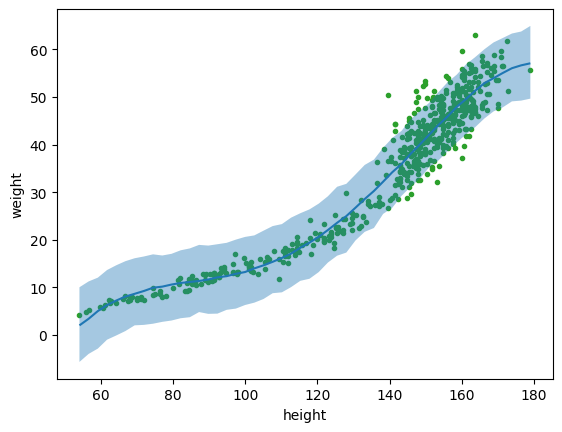

In [12]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
num_knots = 6
min_height = howell.height.min()
max_height = howell.height.max()
knots = np.linspace(min_height, max_height, num_knots+2)[1:-1]
model_spline = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="gaussian") # Changed family to gaussian as weight is continuous
idata_spline = model_spline.fit()

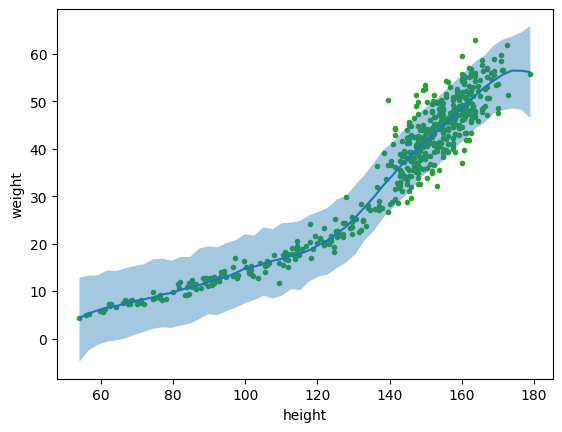

In [15]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
#Guassian process
model_hsb = bmb.Model("weight ~ (height)", howell, family="negativebinomial")
idata_hsb = model_hsb.fit()

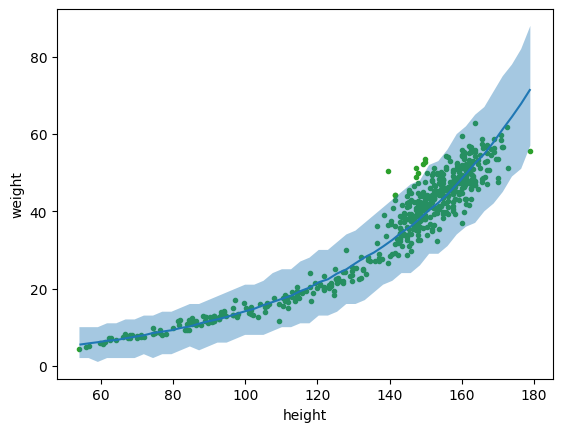

In [22]:
bmb.interpret.plot_predictions(model_hsb, idata_hsb, "height", pps=True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

Covariance measures how much two variables move together. They use this to determine how smooth or variable the predicted curve is.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

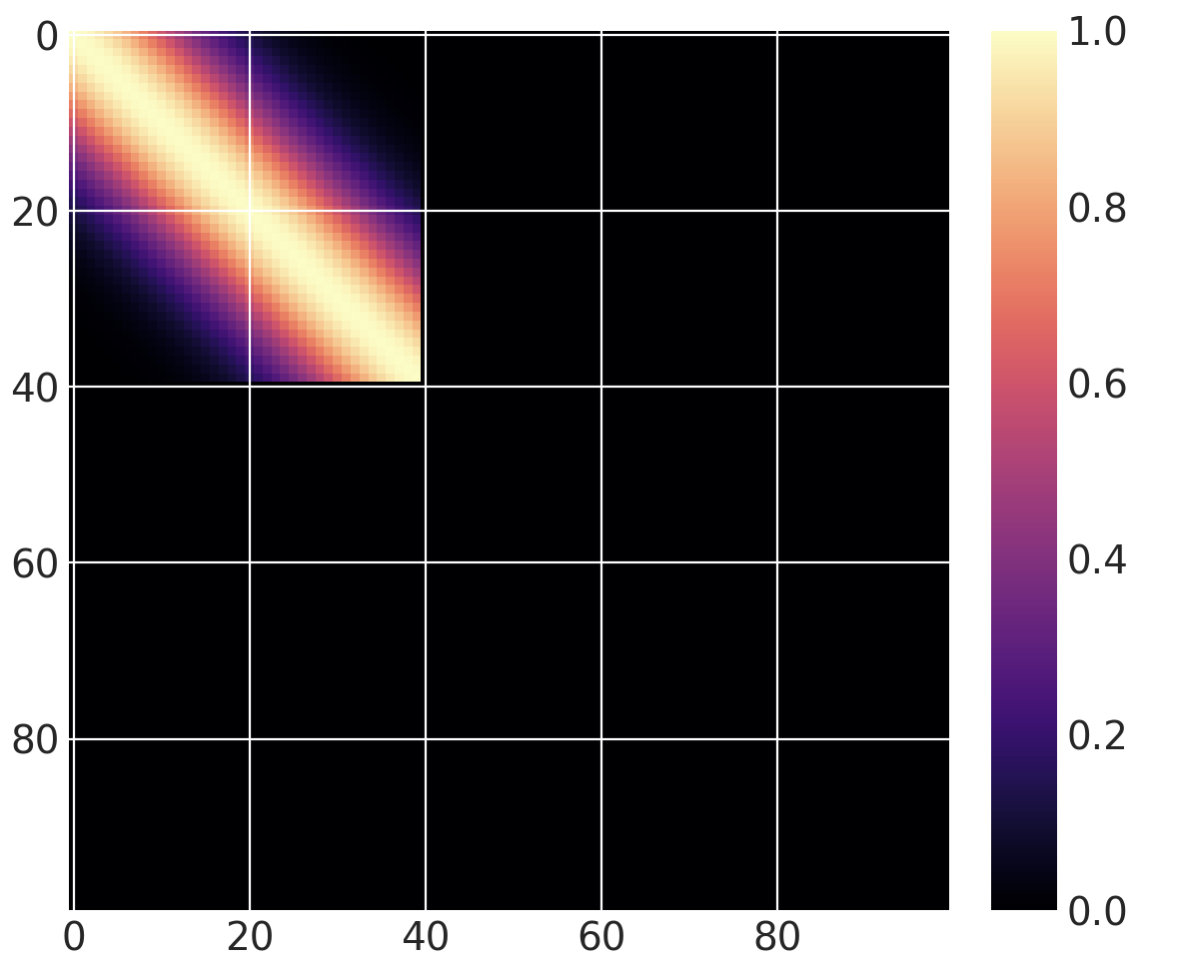



*   This is a heatmap. The x-axis and y-axis are two different timepoints. Each pixel shows how similar two timepoints are expected to be. The lighter the color, the stronger the similarity. The diagonal entries are the brightest because each point is similar to itself a lot.
*   This is my favorite graph because it looks cool and has nice colors.

